<h1 style="color:black; background-color:lightblue; text-align:center;">Plagiarism Detection Model Using TF-IDF and Semantic Analysis</h1>

## **Այս մոդելը համեմատում է փաստաթղթերը երկու տարբեր մեթոդներով՝ TF-IDF և սեմանտիկ վերլուծություն, հաշվարկվում է երկու տեքստերի միջև նմանությունը՝ օգտագործելով cosine_similarity՝  հնարավոր գրագողությունը հայտնաբերելու համար։**


## **Եզրակացություն**
**Տրամադրված մոդելը լավ մոտեցում է գրագողության  հայտնաբերման համար,բայց անհրաժեշտ է կիրառել ավելի առաջադեմ մոդելներ բարձր ճշգրտություն ստանալու համար։**


### Ներմուծենք անհրաժեշտ մոդուլները բնական լեզվի մշակման (NLP) և տվյալների վերլուծության համար

In [1]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations  #itertools.combinations - Գործիք, որը թույլ է տալիս ստեղծել կոմբինացիաներ տրված տարրերից
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer   #sentence_transformers - Գործիք, որը թույլ է տալիս ստեղծել նախադասությունների վեկտորներ:

# Install SentencePiece library
try:
    import sentencepiece   #SentencePiece գրադարանը օգտագործվում է տեքստի նախամշակման համար
except ImportError:
    import os
    os.system('pip install sentencepiece')
from transformers import MarianMTModel, MarianTokenizer   #MarianMTModel և MarianTokenizer մոդելները օգտագործվում են թարգմանության համար

#### nltk - Բնական լեզվի մշակման գրադարան, որը ներառում է տարբեր մոդուլներ տեքստի մշակման համար: <br>
**stopwords** - Հեռացնելու համար մեծ կարևորություն չունեցող բառերը, ինչպիսիք են «և», «որ», «մեջ», ինչպես նաև հոդերը ու դերանունները, որոնք ունեն նվազագույն սեմանտիկ արժեք։<br>
**word_tokenize, sent_tokenize** - Տեքստի բաժանում բառերի և նախադասությունների:<br>
**WordNetLemmatizer** - Լեմմատիզացման գործիք, որը  բառերը փոխարկում է իրենց բառարանային հիմքային ձևին, ինչը նպաստել է համեմատական վերլուծության ճշգրտությանը։ Օրինակ՝ «արտադրված» բառը վերածվել է «արտադրել» ձևի։<br>


#### sklearn - Մեքենայական ուսուցման գրադարանից ներմուծվել են հետևյալ մոդուլները․
**TfidfVectorizer** - Տեքստի վեկտորացման գործիք, որը հաշվում է Տերմ-հաճախականություն-հակառակ փաստաթղթի հաճախականությունը (TF-IDF):
**cosine_similarity** - Կոսինուսի նմանության հաշվարկման գործիք:

In [2]:
# Initialize translation models and tokenizers
translation_models = {}
translation_tokenizers = {}

# Հասանելի լեզուների զույգերի ցանկ
language_pairs = {
    'English to Albanian': 'Helsinki-NLP/opus-mt-en-sq',
    'English to Arabic': 'Helsinki-NLP/opus-mt-en-ar',
    'English to Armenian': 'Helsinki-NLP/opus-mt-en-hy',
    'English to Azerbaijani': 'Helsinki-NLP/opus-mt-en-az',
    'English to Bulgarian': 'Helsinki-NLP/opus-mt-en-bg',
    'English to Chinese': 'Helsinki-NLP/opus-mt-en-zh',
    'English to Czech': 'Helsinki-NLP/opus-mt-en-cs',
    'English to Danish': 'Helsinki-NLP/opus-mt-en-da',
    'English to Dutch': 'Helsinki-NLP/opus-mt-en-nl',
    'English to Filipino': 'Helsinki-NLP/opus-mt-en-tl',
    'English to Finnish': 'Helsinki-NLP/opus-mt-en-fi',
    'English to French': 'Helsinki-NLP/opus-mt-en-fr',
    'English to German': 'Helsinki-NLP/opus-mt-en-de',
    'English to Greek': 'Helsinki-NLP/opus-mt-en-el',
    'English to Hindi': 'Helsinki-NLP/opus-mt-en-hi',
    'English to Hungarian': 'Helsinki-NLP/opus-mt-en-hu',
    'English to Icelandic': 'Helsinki-NLP/opus-mt-en-is',
    'English to Indonesian': 'Helsinki-NLP/opus-mt-en-id',
    'English to Irish': 'Helsinki-NLP/opus-mt-en-ga',
    'English to Italian': 'Helsinki-NLP/opus-mt-en-it',
    'English to Romanian': 'Helsinki-NLP/opus-mt-en-ro',
    'English to Russian': 'Helsinki-NLP/opus-mt-en-ru',
    'English to Spanish': 'Helsinki-NLP/opus-mt-en-es',
    'English to Swedish': 'Helsinki-NLP/opus-mt-en-sv',
    'English to Ukrainian': 'Helsinki-NLP/opus-mt-en-uk',
    'English to Xhosa': 'Helsinki-NLP/opus-mt-en-xh',
    'Albanian to English': 'Helsinki-NLP/opus-mt-sq-en',
    'Armenian to English': 'Helsinki-NLP/opus-mt-hy-en',
    'Azerbaijani to English': 'Helsinki-NLP/opus-mt-az-en',
    'French to English': 'Helsinki-NLP/opus-mt-fr-en',
    'Spanish to English': 'Helsinki-NLP/opus-mt-es-en',
    'Italian to English': 'Helsinki-NLP/opus-mt-it-en',
    'German to English': 'Helsinki-NLP/opus-mt-de-en',
    'Chinese to English': 'Helsinki-NLP/opus-mt-zh-en',
    'Greek to English': 'Helsinki-NLP/opus-mt-el-en',
    # more pairs if needed
}

### Այս կոդը բեռնում է և օգտագործում է թարգմանական մոդելներ MarianMT-ի հիման վրա, որպեսզի թարգմանի փաստաթղթերի տեքստը մեկ լեզվից մյուսը։

In [3]:
def load_translation_model(language_pair):
    model_name = language_pairs[language_pair]
    translation_tokenizers[language_pair] = MarianTokenizer.from_pretrained(model_name)
    translation_models[language_pair] = MarianMTModel.from_pretrained(model_name)

def translate_text(text, source_language, target_language):
    language_pair = f"{source_language} to {target_language}"
    if language_pair not in translation_models:
        load_translation_model(language_pair)
    
    tokenizer = translation_tokenizers[language_pair]
    model = translation_models[language_pair]

    tokenized_text = tokenizer([text], return_tensors='pt', padding=True)
    translation = model.generate(**tokenized_text)
    translated_text = tokenizer.batch_decode(translation, skip_special_tokens=True)[0]

    return translated_text

In [4]:
# Download necessary NLTK data
nltk.download('stopwords', quiet=True)  #Stopwords are common words like "and", "the", "is", etc
nltk.download('punkt', quiet=True)       #The punkt tokenizer is used to split text into sentences.
nltk.download('wordnet', quiet=True)      #WordNet is a lexical database for the English language. It can be used for lemmatization, finding synonyms, antonyms, etc.


True

In [5]:
# Initialize stopwords, lemmatizer, and sentence transformer
stop_words = set(stopwords.words('english'))  #ստեղծում է կանգառ բառերի հավաքածու (set), որը հեշտացնում է նրանց հետագա հեռացումը տեքստից:
lemmatizer = WordNetLemmatizer()               #ստեղծում է լեմմատիզատոր WordNetLemmatizer օբյեկտը nltk գրադարանից(օրինակ՝ "running" -> "run"):
sentence_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')    #Մոդելը՝ paraphrase-MiniLM-L6-v2, օգտագործվում է նախադասությունների վեկտորիզացման համար,  այն փոխակերպում է նախադասությունները վեկտորների՝ թվային ներկայացումների:


### Գրենք preprocess_text ֆունկցիան, որով մշակելու ենք տեքստը․
##### Տեքստը դարձնենք փոքրատառ
##### Հեռացնենք կետադրությունը
##### Տեքստը բաժանենք բառերի
##### Եթե remove_stopwords=True, ապա հեռացնենք կանգառ բառերը
##### Եթե lemmatize=True, ապա լեմմատիզացնենք բառերը

In [6]:
def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """Preprocess the text: lowercase, remove punctuation, tokenize, optionally remove stopwords and lemmatize."""
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = word_tokenize(text)
    if remove_stopwords:
        words = [word for word in words if word not in stop_words]
    if lemmatize:
        words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)   # Վերադարձնենք մշակված բառերը որպես միավորված տեքստ


### calculate_similarity ֆունկցիան  նախատեսված է երկու փաստաթղթերի միջև նմանությունը հաշվարկելու համար՝ օգտագործելով TF-IDF կամ սեմանտիկ embedding-ներ:
**Ֆունկցիան ընդունում է երեք պարամետր՝ <br>
doc1: Առաջին փաստաթուղթը (տեքստի ձևով),<br>
doc2: Երկրորդ փաստաթուղթը (տեքստի ձևով),<br>
method: Նմանությունը հաշվարկելու մեթոդը, որը կարող է լինել 'tfidf' կամ 'semantic'.**

In [7]:
def calculate_similarity(doc1, doc2, method='tfidf'):
    """Calculate similarity between two documents using TF-IDF or semantic embeddings."""
    if method == 'tfidf':
        vectorizer = TfidfVectorizer()
        tfidf_matrix = vectorizer.fit_transform([doc1, doc2])   #Տեքստերը վերածվում են TF-IDF մատրիցայի՝ օգտագործելով fit_transform մեթոդը
        return cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]  #Հաշվարկվում է կոսինուսի նմանությունը երկու տեքստերի միջև՝ օգտագործելով cosine_similarity:Վերադարձվում է կոսինուսի նմանության արժեքը:
    elif method == 'semantic':
        embeddings = sentence_model.encode([doc1, doc2])   #Տեքստերը կոդավորվում են սեմանտիկ embedding-ների՝ օգտագործելով նախադասության մոդելը (այստեղ՝ sentence_model):Տեքստերը կոդավորվում են սեմանտիկ embedding-ների՝ օգտագործելով նախադասության մոդելը (այստեղ՝ sentence_model):Վերադարձվում է կոսինուսի նմանության արժեքը:
        return cosine_similarity(embeddings)[0][1]


### compare_multiple_documents ֆունկցիան նախատեսված է մի քանի փաստաթղթերի միջև համեմատություն կատարելու և յուրաքանչյուր զույգերի համար նմանությունները հաշվարկելու համար:
**Ֆունկցիան ընդունում է հետևյալ պարամետրերը՝<br>
documents: Փաստաթղթերի ցանկ (տեքստերի ցուցակ):<br>
remove_stopwords: Boolean արժեք, որը ցույց է տալիս կանգառ բառերը հեռացնելու անհրաժեշտությունը:<br>
lemmatize: Boolean արժեք, որը ցույց է տալիս լեմմատիզացիայի անհրաժեշտությունը:<br>
method: Նմանությունը հաշվարկելու մեթոդը՝ 'tfidf' կամ 'semantic':**

In [8]:
def compare_multiple_documents(documents, remove_stopwords=True, lemmatize=True, method='tfidf'):
    """Compare multiple documents and calculate pairwise similarities."""
    processed_docs = [preprocess_text(doc, remove_stopwords, lemmatize) for doc in documents]  #նախամշակում է բոլոր փաստաթղթերը preprocess_text ֆունկցիայի միջոցով և պահում արդյունքները processed_docs ցուցակում
    results = []
    for (i, doc1), (j, doc2) in combinations(enumerate(processed_docs, 1), 2):
        similarity = calculate_similarity(doc1, doc2, method)
        results.append({
            "doc1_id": i,
            "doc2_id": j,
            "similarity": similarity * 100,  # Convert to percentage
            "doc1_processed": doc1,
            "doc2_processed": doc2
        })
    return results

###  plot_similarity_heatmap ֆունկցիան նախատեսված է փաստաթղթերի նմանությունների գծագրման համար օգտագործելով ջերմային քարտեզ (heatmap): Այն օգտագործում է comparison_results արդյունքները՝ փաստաթղթերի միջև զույգերով նմանությունների ցուցակը և փաստաթղթերի քանակը՝ num_documents:

In [9]:
def plot_similarity_heatmap(comparison_results, num_documents):
    """Plot a heatmap of document similarities."""
    similarity_matrix = [[0 for _ in range(num_documents)] for _ in range(num_documents)]
    for result in comparison_results:
        i, j = result['doc1_id'] - 1, result['doc2_id'] - 1
        similarity_matrix[i][j] = similarity_matrix[j][i] = result['similarity']
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(similarity_matrix, annot=True, cmap="YlOrRd", vmin=0, vmax=100)
    plt.title("Document Similarity Heatmap")
    plt.xlabel("Document ID")
    plt.ylabel("Document ID")
    plt.show()

###  generate_similarity_report  ֆունկցիան  ստեղծում է մանրամասն զեկույց փաստաթղթերի միջև նմանությունների մասին և նշում է հնարավոր գրագողության դեպքերը:

In [10]:
def generate_similarity_report(comparison_results, documents, plagiarism_threshold):
    """Generate a detailed similarity report with plagiarism flagging."""
    report = "Detailed Similarity Report\n"
    report += "==========================\n\n"
    
    for result in comparison_results:
        report += f"Document {result['doc1_id']} vs Document {result['doc2_id']}:\n"
        report += f"Similarity: {result['similarity']:.2f}%\n"
        if result['similarity'] > plagiarism_threshold:               #սահմանում է նմանության շեմը, որի դեպքում փաստաթղթերը կդիտարկվեն որպես հնարավոր պլագիատ
            report += "*** POTENTIAL PLAGIARISM DETECTED ***\n"
        report += f"Doc {result['doc1_id']} (original): {documents[result['doc1_id']-1]}\n"
        report += f"Doc {result['doc2_id']} (original): {documents[result['doc2_id']-1]}\n"
        report += f"Doc {result['doc1_id']} (processed): {result['doc1_processed']}\n"
        report += f"Doc {result['doc2_id']} (processed): {result['doc2_processed']}\n\n"
    
    return report

### analyze_document_uniqueness ֆունկցիան  վերլուծում է յուրաքանչյուր փաստաթղթի յուրօրինակությունը՝ հիմնվելով այլ փաստաթղթերին նմանության վրա:

In [11]:
def analyze_document_uniqueness(comparison_results, num_documents):   #comparison_results-ը  պարունակում է փաստաթղթերի միջև զույգերով նմանությունների արդյունքները։num_documents: Փաստաթղթերի քանակը։ 
    """Analyze the uniqueness of each document based on its similarities."""
    uniqueness_scores = [100] * num_documents
    for result in comparison_results:
        i, j = result['doc1_id'] - 1, result['doc2_id'] - 1
        similarity = result['similarity']
        uniqueness_scores[i] -= similarity / (num_documents - 1)
        uniqueness_scores[j] -= similarity / (num_documents - 1)
    return [max(0, score) for score in uniqueness_scores]


### Testing model in English data

Comparing documents using TF-IDF:

Comparing documents using Semantic Analysis:

TF-IDF Analysis Results:

Document 1 vs Document 2:
Similarity: 81.82%
*** POTENTIAL PLAGIARISM DETECTED ***

Document 1 vs Document 3:
Similarity: 0.00%

Document 1 vs Document 4:
Similarity: 22.03%

Document 1 vs Document 5:
Similarity: 29.12%

Document 1 vs Document 6:
Similarity: 0.00%

Document 1 vs Document 7:
Similarity: 0.00%

Document 1 vs Document 8:
Similarity: 0.00%

Document 1 vs Document 9:
Similarity: 0.00%

Document 1 vs Document 10:
Similarity: 0.00%

Document 2 vs Document 3:
Similarity: 0.00%

Document 2 vs Document 4:
Similarity: 19.09%

Document 2 vs Document 5:
Similarity: 25.23%

Document 2 vs Document 6:
Similarity: 0.00%

Document 2 vs Document 7:
Similarity: 0.00%

Document 2 vs Document 8:
Similarity: 0.00%

Document 2 vs Document 9:
Similarity: 0.00%

Document 2 vs Document 10:
Similarity: 0.00%

Document 3 vs Document 4:
Similarity: 0.00%

Document 3 vs Document 5:
Similarity: 

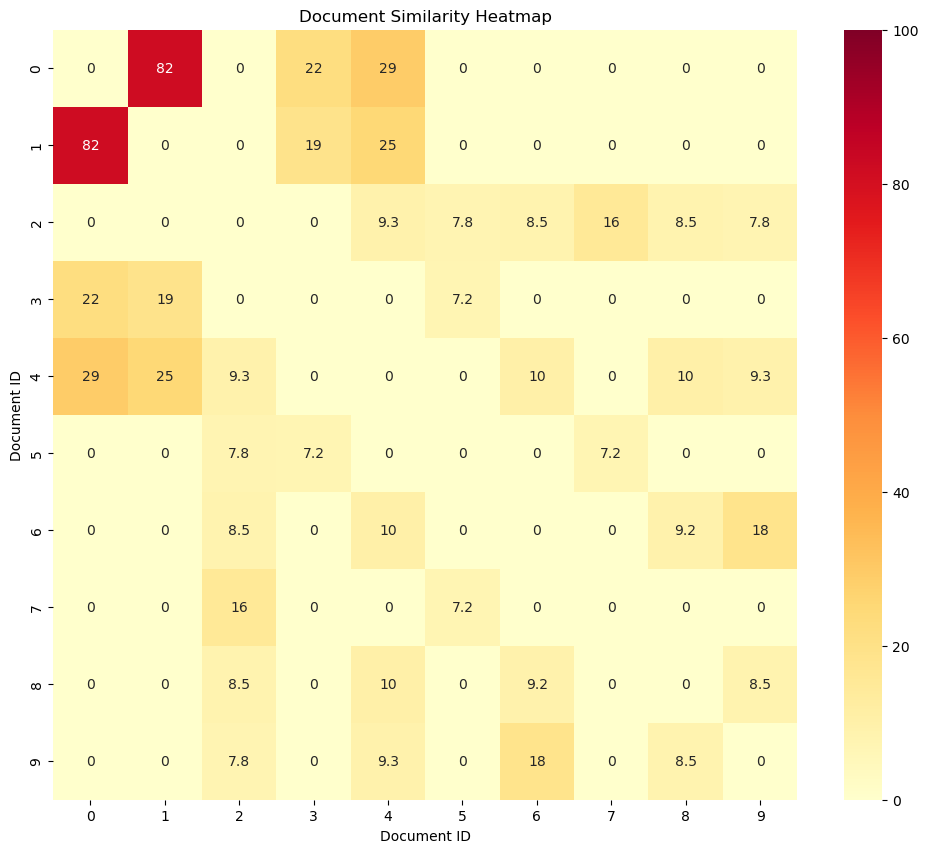


TF-IDF Document Uniqueness Scores:
Document 1: 85.23%
Document 2: 85.98%
Document 3: 93.62%
Document 4: 94.63%
Document 5: 89.62%
Document 6: 97.53%
Document 7: 94.86%
Document 8: 97.46%
Document 9: 95.97%
Document 10: 95.11%

TF-IDF similarity results exported to 'tf-idf_similarity_results.csv'

Semantic Analysis Results:

Document 1 vs Document 2:
Similarity: 89.36%
*** POTENTIAL PLAGIARISM DETECTED ***

Document 1 vs Document 3:
Similarity: 59.22%

Document 1 vs Document 4:
Similarity: 56.09%

Document 1 vs Document 5:
Similarity: 60.71%

Document 1 vs Document 6:
Similarity: 46.35%

Document 1 vs Document 7:
Similarity: 53.51%

Document 1 vs Document 8:
Similarity: 39.65%

Document 1 vs Document 9:
Similarity: 35.04%

Document 1 vs Document 10:
Similarity: 49.90%

Document 2 vs Document 3:
Similarity: 55.84%

Document 2 vs Document 4:
Similarity: 48.19%

Document 2 vs Document 5:
Similarity: 67.50%

Document 2 vs Document 6:
Similarity: 46.57%

Document 2 vs Document 7:
Similarity

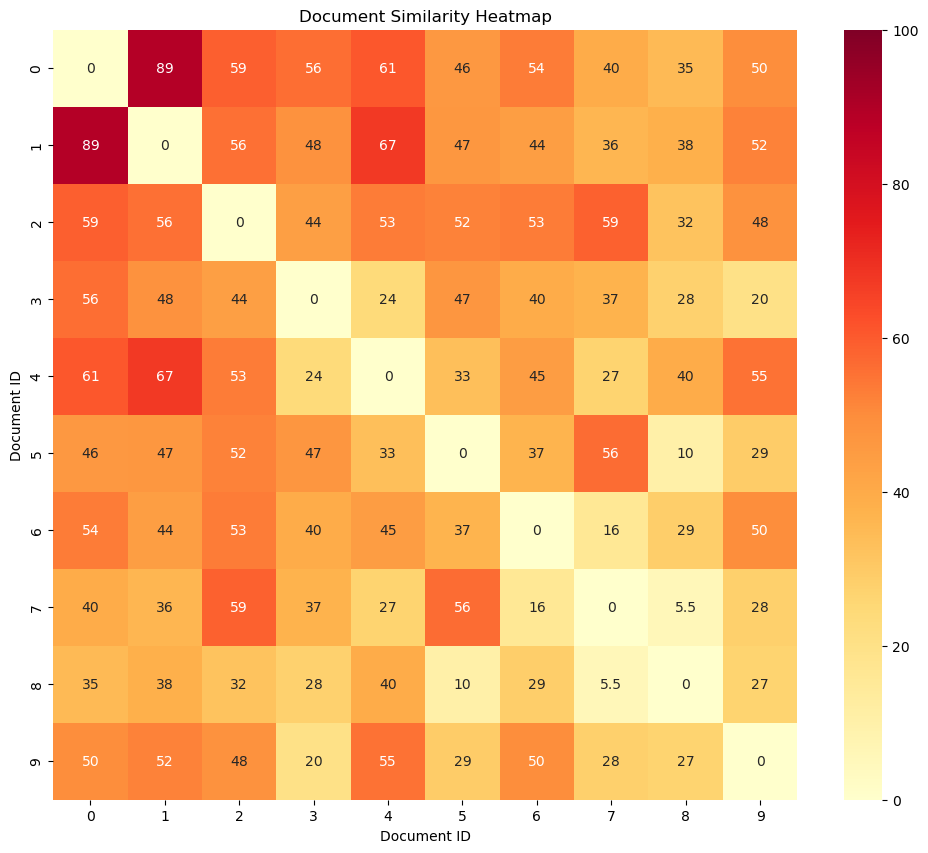


Semantic Document Uniqueness Scores:
Document 1: 45.57%
Document 2: 46.86%
Document 3: 49.22%
Document 4: 61.75%
Document 5: 54.91%
Document 6: 60.17%
Document 7: 59.21%
Document 8: 66.18%
Document 9: 72.87%
Document 10: 60.12%

Semantic similarity results exported to 'semantic_similarity_results.csv'

Analysis complete.


In [12]:
if __name__ == "__main__":
    documents = [
        "Artificial intelligence is the future of technology.",
        "The future of technology lies in artificial intelligence.",
        "Machine learning, a subset of AI, is revolutionizing various industries.",
        "Natural language processing is an important field within artificial intelligence.",
        "The impact of AI on future technology cannot be overstated.",
        "Deep learning algorithms are transforming the field of computer vision.",
        "Robotics and AI are combining to create autonomous systems.",
        "Big data analytics relies heavily on machine learning techniques.",
        "The ethical implications of AI are a topic of ongoing debate.",
        "Quantum computing may revolutionize the capabilities of AI systems."
    ]

    plagiarism_threshold = 70.0  # Set threshold for flagging potential plagiarism

    print("Comparing documents using TF-IDF:")
    tfidf_results = compare_multiple_documents(documents, method='tfidf')
    
    print("\nComparing documents using Semantic Analysis:")
    semantic_results = compare_multiple_documents(documents, method='semantic')

    for method, results in [("TF-IDF", tfidf_results), ("Semantic", semantic_results)]:
        print(f"\n{method} Analysis Results:")
        for result in results:
            print(f"\nDocument {result['doc1_id']} vs Document {result['doc2_id']}:")
            print(f"Similarity: {result['similarity']:.2f}%")
            if result['similarity'] > plagiarism_threshold:
                print("*** POTENTIAL PLAGIARISM DETECTED ***")

        most_similar = max(results, key=lambda x: x['similarity'])
        print(f"\nMost similar pair: Document {most_similar['doc1_id']} and Document {most_similar['doc2_id']}")
        print(f"Similarity: {most_similar['similarity']:.2f}%")

        least_similar = min(results, key=lambda x: x['similarity'])
        print(f"\nLeast similar pair: Document {least_similar['doc1_id']} and Document {least_similar['doc2_id']}")
        print(f"Similarity: {least_similar['similarity']:.2f}%")

        # Generate and save detailed report
        report = generate_similarity_report(results, documents, plagiarism_threshold)
        with open(f"{method.lower()}_similarity_report.txt", "w") as f:
            f.write(report)
        print(f"\nDetailed {method} similarity report saved to '{method.lower()}_similarity_report.txt'")

        # Plot similarity heatmap
        plot_similarity_heatmap(results, len(documents))

        # Analyze document uniqueness
        uniqueness_scores = analyze_document_uniqueness(results, len(documents))
        print(f"\n{method} Document Uniqueness Scores:")
        for i, score in enumerate(uniqueness_scores, 1):
            print(f"Document {i}: {score:.2f}%")

        # Export results to CSV
        df = pd.DataFrame(results)
        df.to_csv(f"{method.lower()}_similarity_results.csv", index=False)
        print(f"\n{method} similarity results exported to '{method.lower()}_similarity_results.csv'")

print("\nAnalysis complete.")

### Testing model in Armenian data

Translated Document 1: The future of innovation technology.
Translated Document 2: The future of technology is in artificial intelligence.
Translated Document 3: The education, the AD, the AM, is going to change different ways.
Translated Document 4: It's an important field of cognitive intelligence.
Translated Document 5: The impact of technology on the future of technology is impossible.
Translated Document 6: The deep-ups of learning change the field of computer theory.
Translated Document 7: It's just going to get together to create system systems.
Translated Document 8: The vast majority of data is greatly influenced by the media technology technology.
Translated Document 9: This is a constant discussion.
Translated Document 10: The count can predict the possibilities of the AMD systems.
Comparing documents using TF-IDF:

Comparing documents using Semantic Analysis:

TF-IDF Analysis Results:

Document 1 vs Document 2:
Similarity: 41.12%

Document 1 vs Document 3:
Similarity: 0.00%

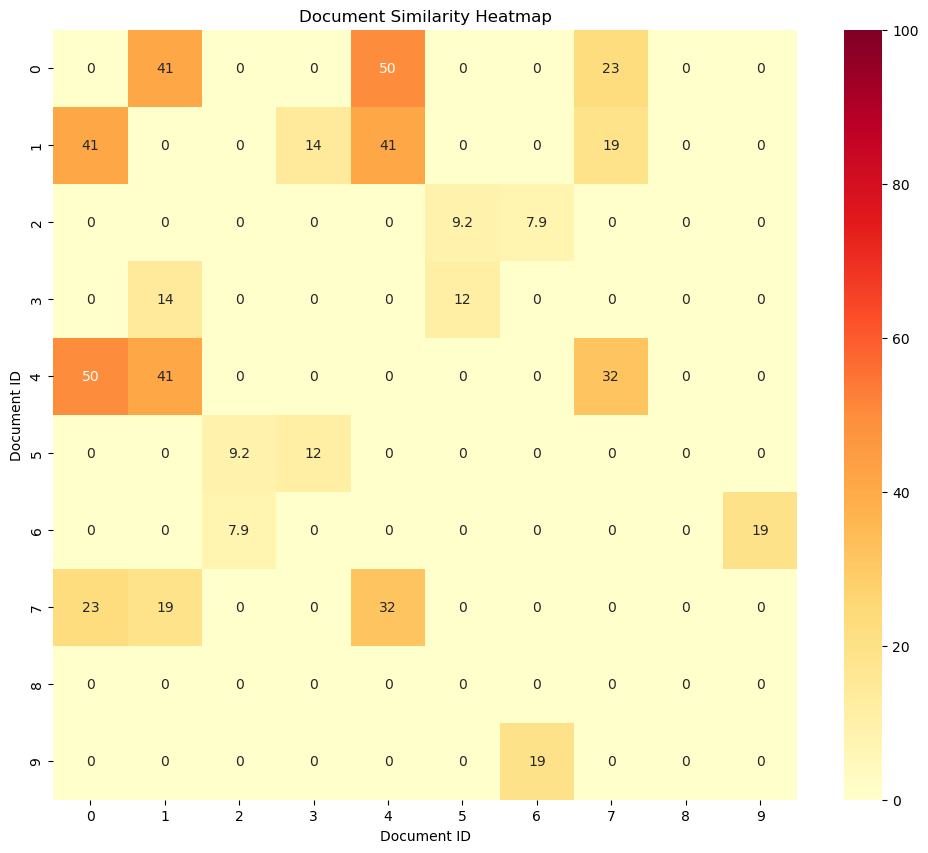


TF-IDF Document Uniqueness Scores:
Document 1: 87.33%
Document 2: 87.14%
Document 3: 98.10%
Document 4: 97.12%
Document 5: 86.30%
Document 6: 97.70%
Document 7: 96.97%
Document 8: 91.83%
Document 9: 100.00%
Document 10: 97.84%

TF-IDF similarity results exported to 'tf-idf_similarity_results.csv'

Semantic Analysis Results:

Document 1 vs Document 2:
Similarity: 67.47%

Document 1 vs Document 3:
Similarity: 35.42%

Document 1 vs Document 4:
Similarity: 22.20%

Document 1 vs Document 5:
Similarity: 59.69%

Document 1 vs Document 6:
Similarity: 18.72%

Document 1 vs Document 7:
Similarity: 23.50%

Document 1 vs Document 8:
Similarity: 46.37%

Document 1 vs Document 9:
Similarity: 6.83%

Document 1 vs Document 10:
Similarity: 22.15%

Document 2 vs Document 3:
Similarity: 29.03%

Document 2 vs Document 4:
Similarity: 49.56%

Document 2 vs Document 5:
Similarity: 46.50%

Document 2 vs Document 6:
Similarity: 42.17%

Document 2 vs Document 7:
Similarity: 25.34%

Document 2 vs Document 8:
Si

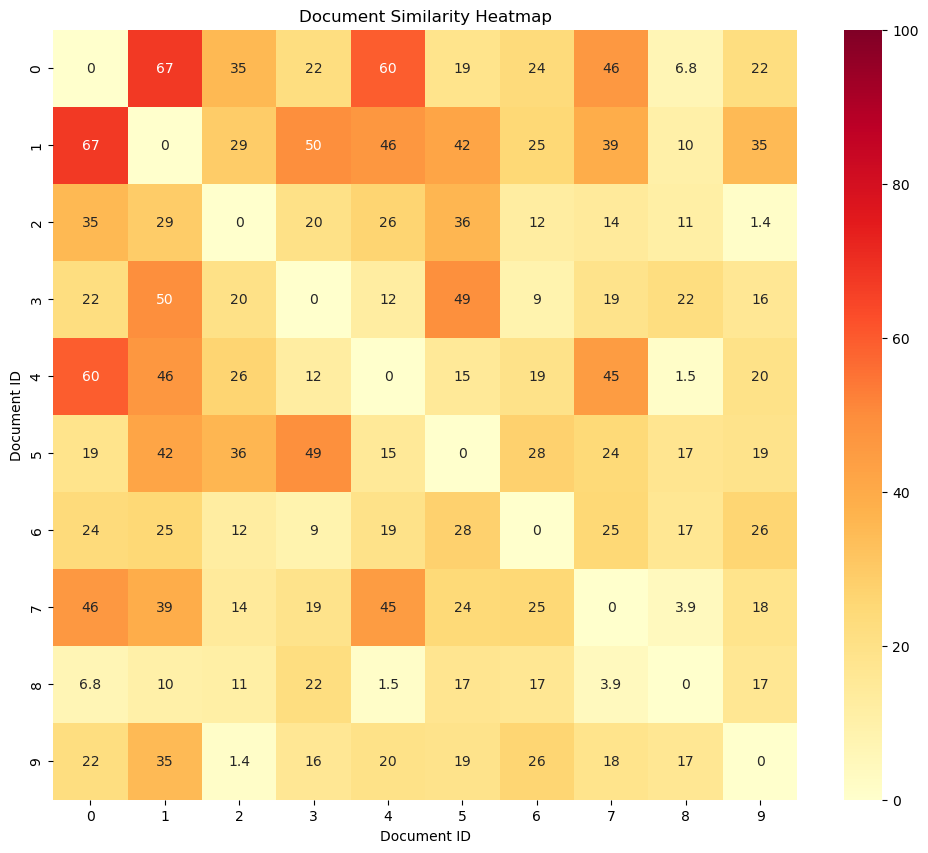


Semantic Document Uniqueness Scores:
Document 1: 66.41%
Document 2: 61.69%
Document 3: 79.35%
Document 4: 75.61%
Document 5: 72.73%
Document 6: 72.30%
Document 7: 79.49%
Document 8: 73.83%
Document 9: 88.15%
Document 10: 80.63%

Semantic similarity results exported to 'semantic_similarity_results.csv'

Analysis complete.


In [13]:
if __name__ == "__main__":
    documents = [
        "Արհեստական բանականությունը տեխնոլոգիայի ապագան է:",
        "Տեխնոլոգիայի ապագան գտնվում է արհեստական բանականության մեջ:",
        "Մեքենայական ուսուցումը, AI-ի ենթաբաժինը, հեղափոխում է տարբեր ոլորտները:",
        "Բնական լեզվի մշակումը արհեստական բանականության կարևոր ոլորտ է:",
        "AI-ի ազդեցությունը տեխնոլոգիայի ապագայի վրա անհնար է գերագնահատել:",
        "Խորը ուսուցման ալգորիթմները փոխում են համակարգչային տեսության ոլորտը:",
        "Ռոբոտները և AI-ը համատեղվում են՝ ինքնավար համակարգեր ստեղծելու համար:",
        "Մեծ տվյալների անալիտիկան մեծապես կախված է մեքենայական ուսուցման տեխնիկաներից:",
        "AI-ի էթիկական ենթատեքստերը մշտապես քննարկման թեմա են:",
        "Քվանտային հաշվարկումը կարող է հեղափոխել AI համակարգերի հնարավորությունները:"
    ]

    
    # Example translation
    for i in range(len(documents)):
        documents[i] = translate_text(documents[i], 'Armenian', 'English')
        print(f"Translated Document {i + 1}: {documents[i]}")

    plagiarism_threshold = 70.0  # Set threshold for flagging potential plagiarism

    print("Comparing documents using TF-IDF:")
    tfidf_results = compare_multiple_documents(documents, method='tfidf')
    
    print("\nComparing documents using Semantic Analysis:")
    semantic_results = compare_multiple_documents(documents, method='semantic')

    for method, results in [("TF-IDF", tfidf_results), ("Semantic", semantic_results)]:
        print(f"\n{method} Analysis Results:")
        for result in results:
            print(f"\nDocument {result['doc1_id']} vs Document {result['doc2_id']}:")
            print(f"Similarity: {result['similarity']:.2f}%")
            if result['similarity'] > plagiarism_threshold:
                print("*** POTENTIAL PLAGIARISM DETECTED ***")

        most_similar = max(results, key=lambda x: x['similarity'])
        print(f"\nMost similar pair: Document {most_similar['doc1_id']} and Document {most_similar['doc2_id']}")
        print(f"Similarity: {most_similar['similarity']:.2f}%")

        least_similar = min(results, key=lambda x: x['similarity'])
        print(f"\nLeast similar pair: Document {least_similar['doc1_id']} and Document {least_similar['doc2_id']}")
        print(f"Similarity: {least_similar['similarity']:.2f}%")

        # Generate and save detailed report
        report = generate_similarity_report(results, documents, plagiarism_threshold)
        with open(f"{method.lower()}_similarity_report.txt", "w") as f:
            f.write(report)
        print(f"\nDetailed {method} similarity report saved to '{method.lower()}_similarity_report.txt'")

        # Plot similarity heatmap
        plot_similarity_heatmap(results, len(documents))

        # Analyze document uniqueness
        uniqueness_scores = analyze_document_uniqueness(results, len(documents))
        print(f"\n{method} Document Uniqueness Scores:")
        for i, score in enumerate(uniqueness_scores, 1):
            print(f"Document {i}: {score:.2f}%")

        # Export results to CSV
        df = pd.DataFrame(results)
        df.to_csv(f"{method.lower()}_similarity_results.csv", index=False)
        print(f"\n{method} similarity results exported to '{method.lower()}_similarity_results.csv'")

print("\nAnalysis complete.")

### Մոդելի Լավ Կողմերը
Մոդելը համեմատում է տեքստերը երկու տարբեր մեթոդներով՝ TF-IDF և սեմանտիկ վերլուծություն, ինչը թույլ է տալիս հայտնաբերել ինչպես ճշգրիտ, այնպես և վերամշակված բովանդակությունը: Մոդելը ստեղծում է մանրամասն զեկույցներ, որոնք օգնում են հասկանալ փաստաթղթերի միջև նմանությունները և հեշտացնում են պլագիատի հնարավոր դեպքերի հայտնաբերումը: Մոդելը գնահատում է յուրաքանչյուր փաստաթղթի յուրահատկությունը, ինչը թույլ է տալիս պարզել, թե որ փաստաթղթերն են ավելի եզակի:
### Մոդելի Վատ Կողմերը
Շատ վատ արդյունքներ է ցուցաբերում մոդելը այլ լեզվից փաստաթուղթը անգլերեն թարգմանելու և գրագողությունը վերլուծելու դեպքում։<br>
Օրինակ **"Արհեստական բանականությունը տեխնոլոգիայի ապագան է:",<br>
"Տեխնոլոգիայի ապագան գտնվում է արհեստական բանականության մեջ:"**,<br>
այս 2 նախադասություները 95%  նմանություն են ցուցաբերում, բայց թարգմաներլով translate_text() ֆունկցիայի միջոցով այնուհետև կիրառելով նույն մոդելը ստանում ենք ցածր արժեք(Similarity: 41.12%):<br>
Սա շտկելու համար  անհրաժեշտ է կիրառել մի քանի քայլեր, որոնք կօգնեն բարելավել մոդելի կատարողականությունը: 1. Օգտագործենք բարձրորակ թարգմանության մոդելներ, ինչպիսիք են Google's Translation API(արված է), DeepL, կամ OpenAI-ի GPT մոդելները: 
### Կատարելագործման Հնարավորություններ
Կարող ենք կիրառել ավելի առաջադեմ սեմանտիկ մոդելներ, ինչպիսիք են BERT-ը  կամ GPT(հաջորդիվ), ինչը կբարելավի սեմանտիկ վերլուծության արդյունքները: Կիրառել համատեքստային մոդելներ(contextual models) , որոնք հաշվի կառնեն ոչ միայն բառերի, այլև նախադասությունների և պարբերության համատեքստերը: Կիրառել ավելի ճշգրիտ շեմեր, որոնք կբացառեն սխալ դրական(FP) և սխալ բացասական(FN) դեպքերը՝ պլագիատի հայտնաբերման ժամանակ: